# 20 · Opto — Expert / Uniform

Does PPC silencing affect **expert** behaviour on Uniform? Descriptive — effect
sizes and CIs first; the tests are a map, not a verdict (n≈4 vs 5).

**Three contrasts, each per animal then folded WT vs HET:**
1. **1c — within-session**, opto on vs off. The rig randomised laser per trial, so
   permutation-valid. The direct 'what does a laser trial do' effect.
2. **2b — between-session**, opto session vs masking session, **all trials** (the
   on-trials *are* the effect we want). Bootstrap only (session type isn't
   randomised per trial). 'Does an opto session differ from a masking session.'
3. **2a — interaction**, `[opto(on−off)] − [masking(on−off)]`. Cancels the shared
   light artifact, leaving silencing. Bootstrap only.

**Reading the channel.** side_bias (marginal P(B)−0.5) and PSE (`mu`) are both in
the panel: a shift in side_bias with PSE spared = a stimulus-independent additive
offset (a light artifact), not a criterion move; `recency` (spared by the light
in prior work) points the same way. A reading of the same panel, not a separate
analysis — note d′/criterion are not computed here (`side_bias` vs PSE carry it).

Post-shift (Hard-A/Hard-B) is nb 21.

In [1]:
from shared_setup import *
from plotting.opto import plot_delta_swarm
apply_style()

experiment, info = load_data()
by_animal, groups = gather_genotypes(experiment)
het_ids, wt_ids = groups.get('het', []), groups.get('wt', [])
opto_ids = [a for a in OPTO_COHORT if a in experiment.animals]
print(f"opto cohort ({len(opto_ids)}): het={[a for a in opto_ids if by_animal.get(a)=='het']} "
      f"wt={[a for a in opto_ids if by_animal.get(a)=='wt']}")

Loaded snapshot: 22 animals, 1267 sessions (exported 2026-07-23)
opto cohort (10): het=['SS15', 'SS16', 'SS19', 'SS21', 'SS22', 'SS23'] wt=['SS14', 'SS17', 'SS18', 'SS20']


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:248: UserWarning: Snapshot is 150h old (exported 2026-07-23T14:02:28.443029+00:00). Re-export if new sessions have been collected.
  experiment, meta = load_snapshot(
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:166: UserWarning: 1 animal(s) without genotype metadata: SS12. Add animal_metadata.json (genotype field) or they stay 'unknown'.
  warnings.warn(


In [2]:
DIST = 'Uniform'
# 'psychometric' expands to mu, sigma, lapse_low, lapse_high
STATS = ['accuracy', 'hard_accuracy', 'easy_accuracy', 'recency', 'side_bias', 'psychometric']
SENSITIVITY = ['accuracy', 'hard_accuracy', 'easy_accuracy', 'sigma', 'recency', 'lapse_low', 'lapse_high']
BIAS        = ['mu', 'side_bias']          # the light-artifact channel
DISPLAY     = SENSITIVITY + BIAS

# psychometric re-fits per resample -> minutes/animal at 2000; drop to 1000 to iterate
N_PERM, N_BOOT = 100, 100

def rows_from(diffs, aid):
    return collect_rows([{'stat': k, 'value': float(v)} for k, v in diffs.items()],
                        animal=aid, group=by_animal[aid])

## §2 · Single animal, end to end

**SS16 (HET)** through the pipeline for all three contrasts. The loop in §3 is
exactly these calls.

In [3]:
aid = 'SS16'
animal = experiment.get_animal(aid)
op = select_sessions(animal, distribution=DIST, session_type='opto')
mk = select_sessions(animal, distribution=DIST, session_type='masking')

opto_on,  opto_off = filter_trials(op, trial_type='opto'), filter_trials(op, trial_type='non_opto')
mask_on,  mask_off = filter_trials(mk, trial_type='opto'), filter_trials(mk, trial_type='non_opto')
opto_all, mask_all = filter_trials(op, trial_type='all'),  filter_trials(mk, trial_type='all')

d_opto    = compute_delta_stat({'on': opto_on, 'off': opto_off}, stats=STATS,
                               reference='off', n_permutations=N_PERM, n_bootstrap=N_BOOT)   # 1c
d_mask    = compute_delta_stat({'on': mask_on, 'off': mask_off}, stats=STATS,
                               reference='off', n_permutations=N_PERM, n_bootstrap=N_BOOT)
d_between = compute_delta_stat({'opto': opto_all, 'masking': mask_all}, stats=STATS,
                               reference='masking', n_permutations=0, n_bootstrap=N_BOOT)     # 2b
inter     = compute_interaction(d_opto, d_mask, contrast='on_vs_off')                        # 2a

In [4]:
print(f"{aid} ({by_animal[aid]}) — {animal.n_sessions} sessions")
print(animal.session_table.groupby(['distribution', 'session_type']).size().to_string())
for name, s in [('opto', op), ('masking', mk)]:
    print(f"  {name}: {pool_arrays(filter_trials(s, trial_type='all'))['n_trials']} trials")

SS16 (het) — 54 sessions
distribution  session_type   
Hard-A        masking             3
              opto                3
Hard-B        masking             3
              opto                3
Uniform       alm_control_bi      5
              alm_control_uni     4
              masking             4
              opto                5
              regular            20
              washout             4
  opto: 2205 trials
  masking: 1413 trials


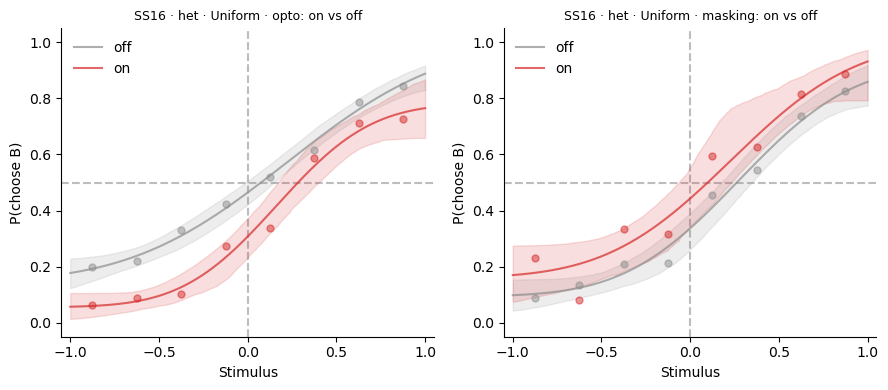

In [5]:
# psychometric overlays — on vs off (opto, masking)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (title, on, off) in zip(axes, [('opto', opto_on, opto_off), ('masking', mask_on, mask_off)]):
    plot_psychometric(compute_psychometric(off), ax=ax, color='0.55', label='off')
    plot_psychometric(compute_psychometric(on),  ax=ax, color=get_colour(3), label='on')
    ax.set_title(f"{aid} · {by_animal[aid]} · {DIST} · {title}: on vs off", fontsize=9); ax.legend(frameon=False)
fig.tight_layout()

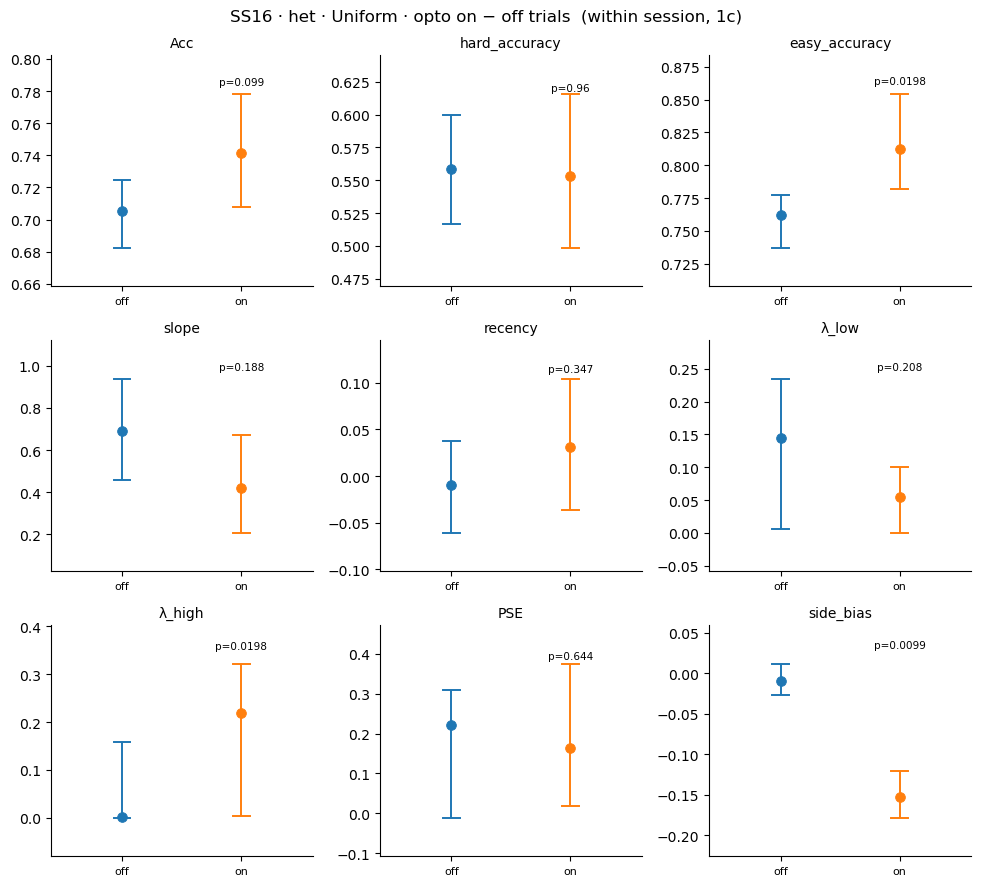

In [6]:
# 1c — opto on vs off, per stat
fig, axes = plt.subplots(3, 3, figsize=(10, 9)); axf = axes.ravel()
for ax, stat in zip(axf, DISPLAY): plot_stat_comparison_single(d_opto, stat, ax=ax)
for ax in axf[len(DISPLAY):]: fig.delaxes(ax)
fig.suptitle(f"{aid} · {by_animal[aid]} · {DIST} · opto on − off trials  (within session, 1c)", fontsize=12); fig.tight_layout()

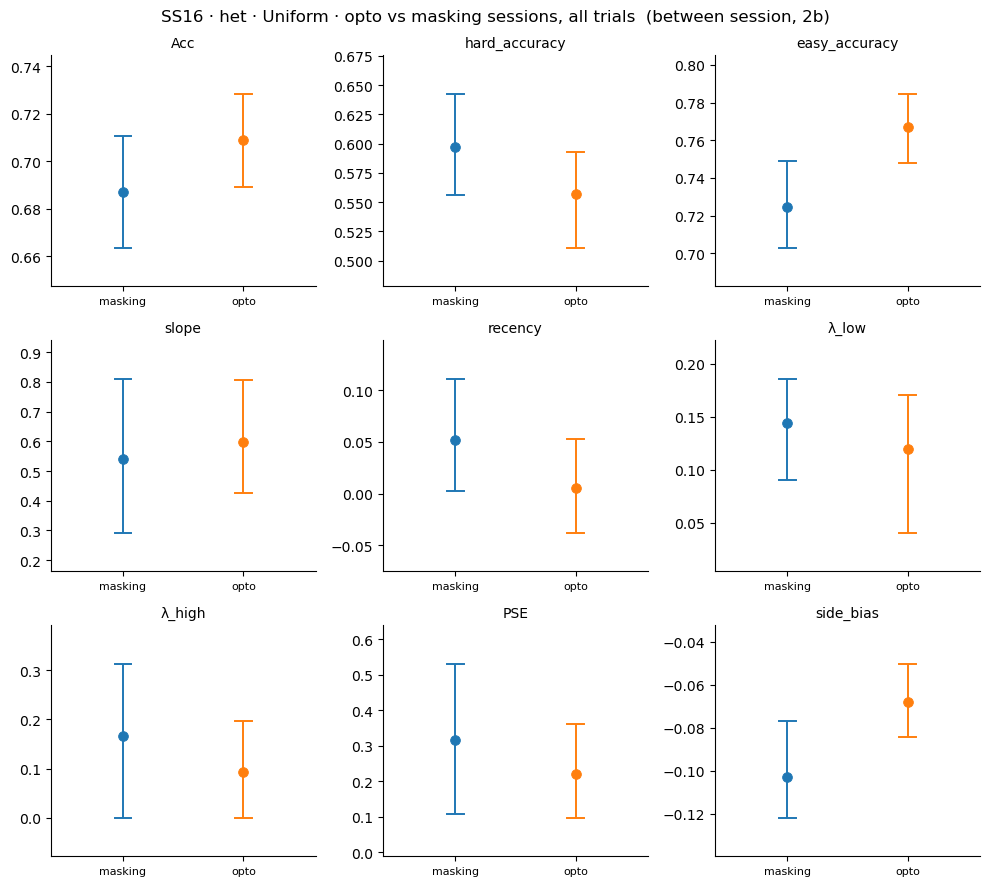

In [7]:
# 2b — opto session vs masking session, all trials, per stat
fig, axes = plt.subplots(3, 3, figsize=(10, 9)); axf = axes.ravel()
for ax, stat in zip(axf, DISPLAY): plot_stat_comparison_single(d_between, stat, ax=ax)
for ax in axf[len(DISPLAY):]: fig.delaxes(ax)
fig.suptitle(f"{aid} · {by_animal[aid]} · {DIST} · opto vs masking sessions, all trials  (between session, 2b)", fontsize=12); fig.tight_layout()

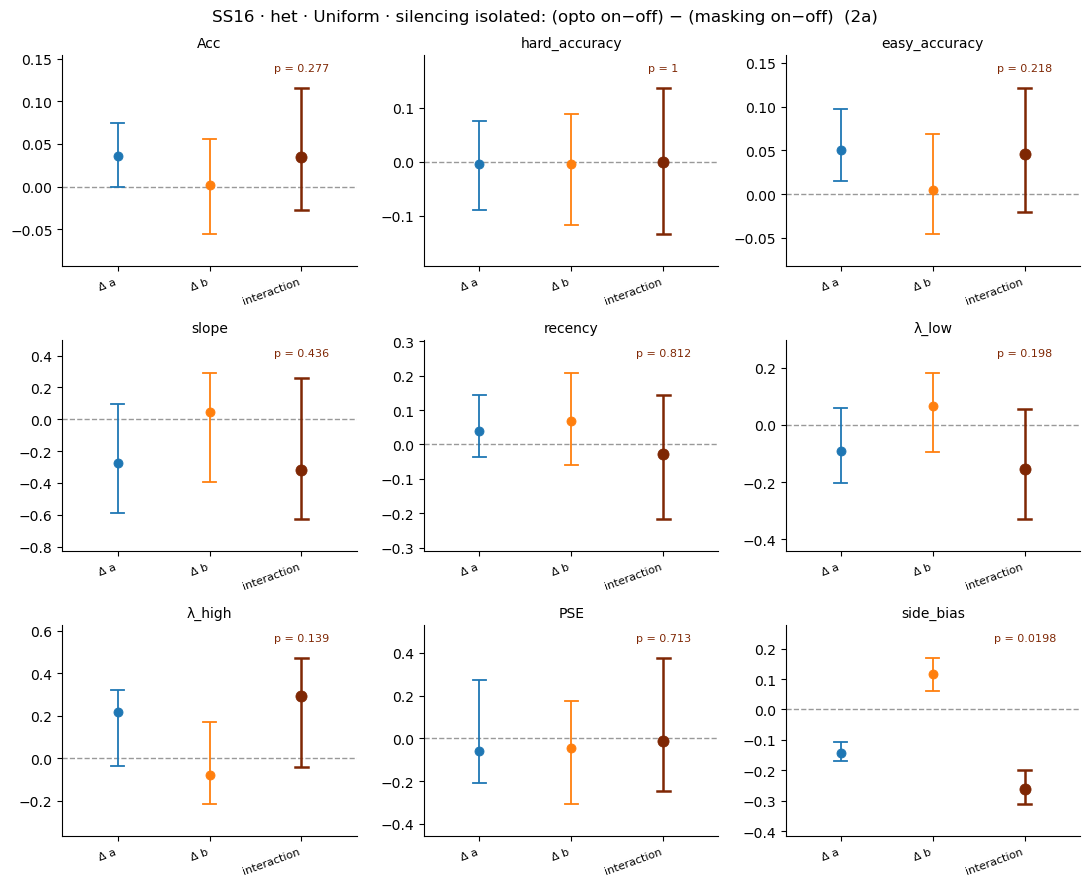

In [8]:
# 2a — interaction: opto-Δ vs masking-Δ vs their difference (silencing beyond artifact)
fig, axes = plt.subplots(3, 3, figsize=(11, 9)); axf = axes.ravel()
for ax, stat in zip(axf, DISPLAY): plot_interaction_single(inter, stat, ax=ax)
for ax in axf[len(DISPLAY):]: fig.delaxes(ax)
fig.suptitle(f"{aid} · {by_animal[aid]} · {DIST} · silencing isolated: (opto on−off) − (masking on−off)  (2a)", fontsize=12); fig.tight_layout()

Text(0.5, 0.98, 'SS16 · het · Uniform · update matrices (opto/masking, on/off)')

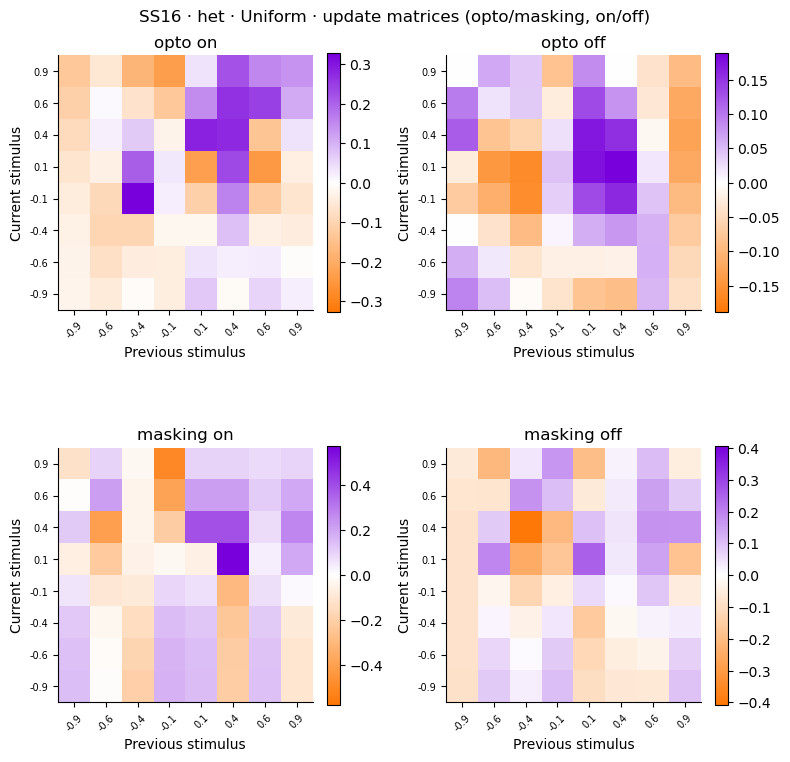

In [9]:
# update matrices — on vs off, opto and masking (descriptive; order-dependent, not folded)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for row, (name, on, off) in enumerate([('opto', opto_on, opto_off), ('masking', mask_on, mask_off)]):
    plot_um(compute_um(on),  ax=axes[row, 0]); axes[row, 0].set_title(f"{name} on")
    plot_um(compute_um(off), ax=axes[row, 1]); axes[row, 1].set_title(f"{name} off")
fig.tight_layout()
fig.suptitle(f"{aid} · {by_animal[aid]} · {DIST} · update matrices (opto/masking, on/off)", fontsize=12)

## §3 · All animals — thin fold

One loop, body = the §2 pipeline. Emits three per-animal `{animal, group, stat,
value}` sets: **1c** (`delta_df`), **2b** (`between_df`), **2a** (`interaction_df`).

In [10]:
delta_rows, between_rows, inter_rows, per_animal = [], [], [], {}
for aid in opto_ids:
    animal = experiment.get_animal(aid)
    op = select_sessions(animal, distribution=DIST, session_type='opto')
    mk = select_sessions(animal, distribution=DIST, session_type='masking')
    oon, ooff = filter_trials(op, trial_type='opto'), filter_trials(op, trial_type='non_opto')
    if not (oon and ooff):
        print(f"skip {aid}: opto on/off missing"); continue
    d_opto = compute_delta_stat({'on': oon, 'off': ooff}, stats=STATS,
                                reference='off', n_permutations=N_PERM, n_bootstrap=N_BOOT)
    delta_rows += rows_from(d_opto['contrasts']['on_vs_off']['diffs'], aid)
    per_animal[aid] = d_opto
    o_all, m_all = filter_trials(op, trial_type='all'), filter_trials(mk, trial_type='all')
    if not (o_all and m_all):
        print(f"note {aid}: no masking — 2b/2a skipped"); continue
    d_between = compute_delta_stat({'opto': o_all, 'masking': m_all}, stats=STATS,
                                   reference='masking', n_permutations=0, n_bootstrap=N_BOOT)
    between_rows += rows_from(d_between['contrasts']['opto_vs_masking']['diffs'], aid)
    mon, moff = filter_trials(mk, trial_type='opto'), filter_trials(mk, trial_type='non_opto')
    if mon and moff:
        d_mask = compute_delta_stat({'on': mon, 'off': moff}, stats=STATS,
                                    reference='off', n_permutations=N_PERM, n_bootstrap=N_BOOT)
        it = compute_interaction(d_opto, d_mask, contrast='on_vs_off')
        inter_rows += collect_rows([{'stat': s, 'value': float(it[s]['interaction'])}
                                    for s in it if s != 'meta'], animal=aid, group=by_animal[aid])

delta_df       = pd.DataFrame(delta_rows)
between_df     = pd.DataFrame(between_rows)
interaction_df = pd.DataFrame(inter_rows)
print(f"1c: {delta_df['animal'].nunique()} | 2b: {between_df['animal'].nunique() if len(between_df) else 0} "
      f"| 2a: {interaction_df['animal'].nunique() if len(interaction_df) else 0} animals")

skip SS19: opto on/off missing
note SS20: no masking — 2b/2a skipped
1c: 9 | 2b: 8 | 2a: 8 animals


## §4 · Population — WT vs HET

Unit = animals. Effect size first; `p`/`min_p` a map (smallest two-sided p ≈ 0.016
at this n). Each contrast folded WT vs HET. Read the **bias** stats (side_bias, mu)
as the light-artifact channel; the **sensitivity** stats as the performance channel
spared by the artifact.

**On p-values:** 1c is permutation-valid (laser randomised per trial). 2b and 2a are
**bootstrap only** — session type isn't randomised per trial, so there is no valid
within-animal permutation p; read their per-animal effect from the bootstrap CI. The
p annotated on every swarm below is the *genotype* WT-vs-HET rank test, which is
valid for all three.

In [11]:
import math
def genotype_table(df):
    res = compare_groups(df, group_col='group')
    tbl = pd.DataFrame([{'stat': s, 'median_wt': r.get('median_a'), 'median_het': r.get('median_b'),
                         'p': r.get('p'), 'min_p': r.get('min_p')} for s, r in res.items()]
                       ).set_index('stat').reindex(DISPLAY).round(4)
    return res, tbl

def swarm_grid(df, res, title):
    ncols = 4; nrows = math.ceil(len(DISPLAY) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.3 * nrows), squeeze=False); axf = axes.ravel()
    for ax, stat in zip(axf, DISPLAY):
        plot_delta_swarm(df, stat, ax=ax, p_value=res.get(stat, {}).get('p'),
                         group_col='group', value_col='value')
    for ax in axf[len(DISPLAY):]: fig.delaxes(ax)
    fig.suptitle(title, fontsize=13); fig.tight_layout()

,median_wt,median_het,p,min_p
stat,,,,
accuracy,-0.0206,0.0006,0.1905,0.0159
hard_accuracy,-0.0111,-0.0049,0.7302,0.0159
easy_accuracy,-0.0278,0.0030,0.1905,0.0159
sigma,-0.1539,-0.0584,0.9048,0.0159
recency,0.0036,0.0120,0.4127,0.0159
lapse_low,-0.0219,-0.0074,0.4127,0.0159
lapse_high,0.0000,0.0140,0.7086,0.0159
mu,0.1893,0.0061,0.0159,0.0159
side_bias,-0.1173,-0.0461,0.1111,0.0159


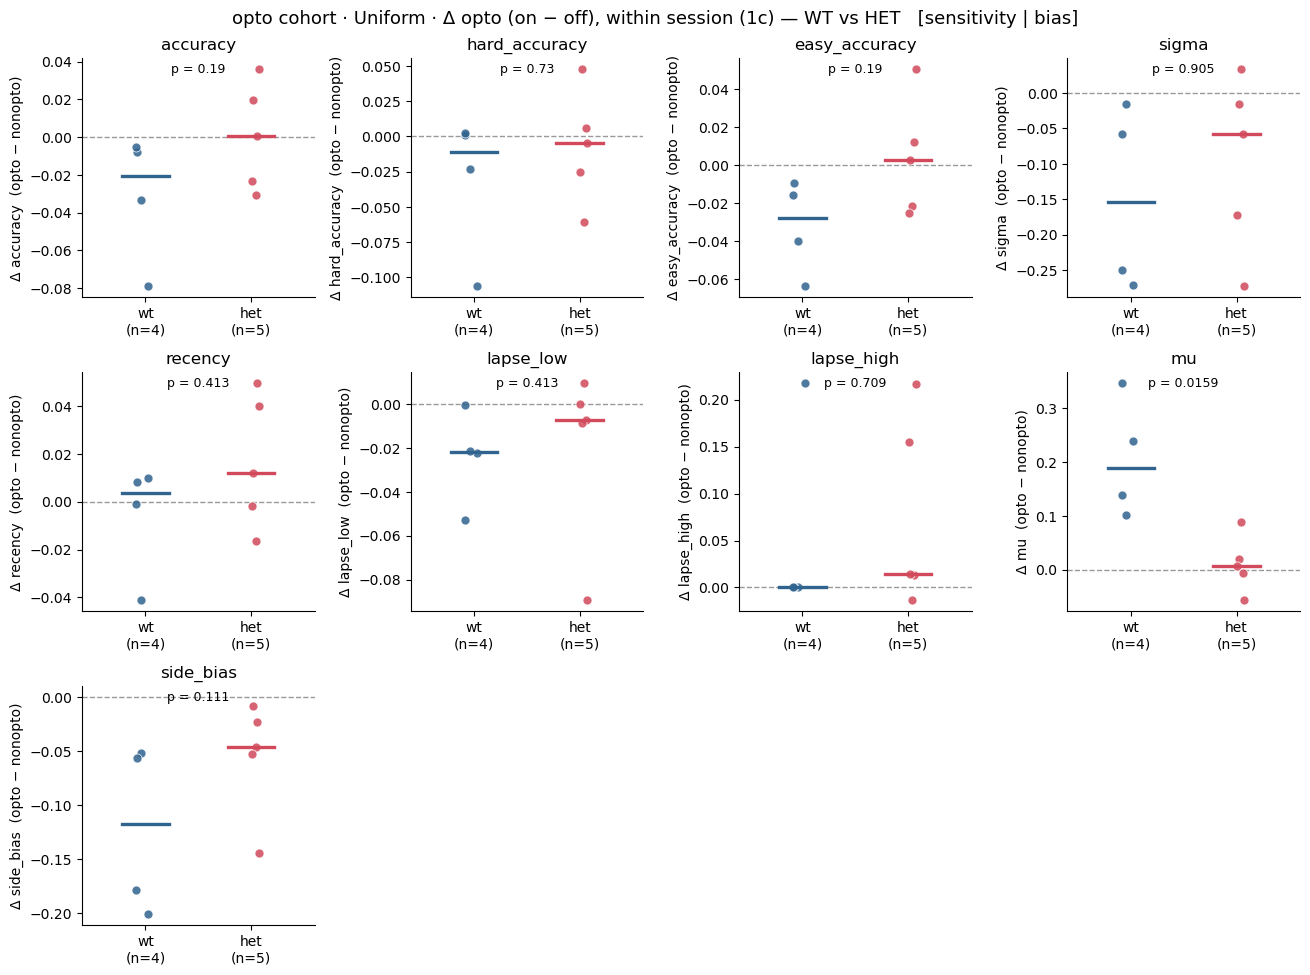

In [12]:
# §4a — 1c (within-session on vs off), WT vs HET
res_1c, tbl_1c = genotype_table(delta_df)
swarm_grid(delta_df, res_1c, f'opto cohort · {DIST} · Δ opto (on − off), within session (1c) — WT vs HET   [sensitivity | bias]')
tbl_1c

               median_wt  median_het       p   min_p
stat                                                
accuracy          0.0521      0.0251  0.5714  0.0357
hard_accuracy     0.0001      0.0112  0.7857  0.0357
easy_accuracy     0.0663      0.0423  0.5714  0.0357
sigma            -0.0023     -0.0199  0.5714  0.0357
recency          -0.0378      0.0048  0.3929  0.0357
lapse_low        -0.0435     -0.0641  0.7857  0.0357
lapse_high       -0.0632     -0.0100  0.3929  0.0357
mu               -0.1385      0.0564  0.2500  0.0357
side_bias         0.0314     -0.0689  0.2500  0.0357


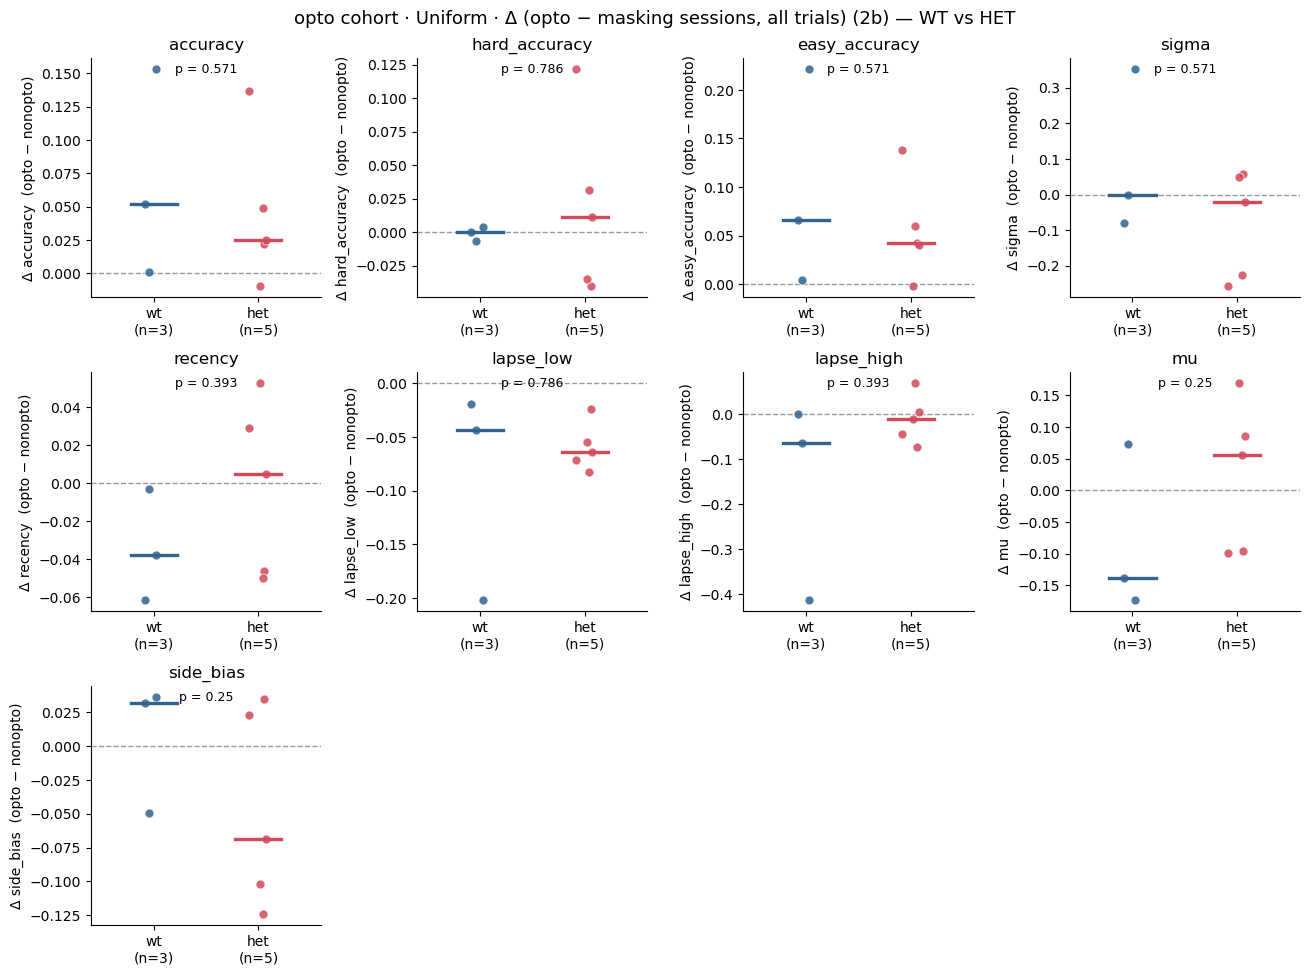

In [13]:
# §4b — 2b (between-session opto vs masking, all trials), WT vs HET
if len(between_df):
    res_2b, tbl_2b = genotype_table(between_df)
    swarm_grid(between_df, res_2b, f'opto cohort · {DIST} · Δ (opto − masking sessions, all trials) (2b) — WT vs HET')
    display(tbl_2b) if 'display' in dir() else print(tbl_2b.to_string())
else:
    print('No between-session rows (masking missing).')

               median_wt  median_het       p   min_p
stat                                                
accuracy         -0.0376     -0.0080  0.1429  0.0357
hard_accuracy    -0.0844      0.0020  0.3929  0.0357
easy_accuracy    -0.0526     -0.0067  0.2500  0.0357
sigma            -0.1207     -0.0222  1.0000  0.0357
recency          -0.0048      0.0175  0.5714  0.0357
lapse_low         0.0208     -0.0221  0.1429  0.0357
lapse_high        0.0000      0.0169  0.5714  0.0357
mu                0.2852      0.0631  0.1429  0.0357
side_bias        -0.1539     -0.0787  0.3929  0.0357


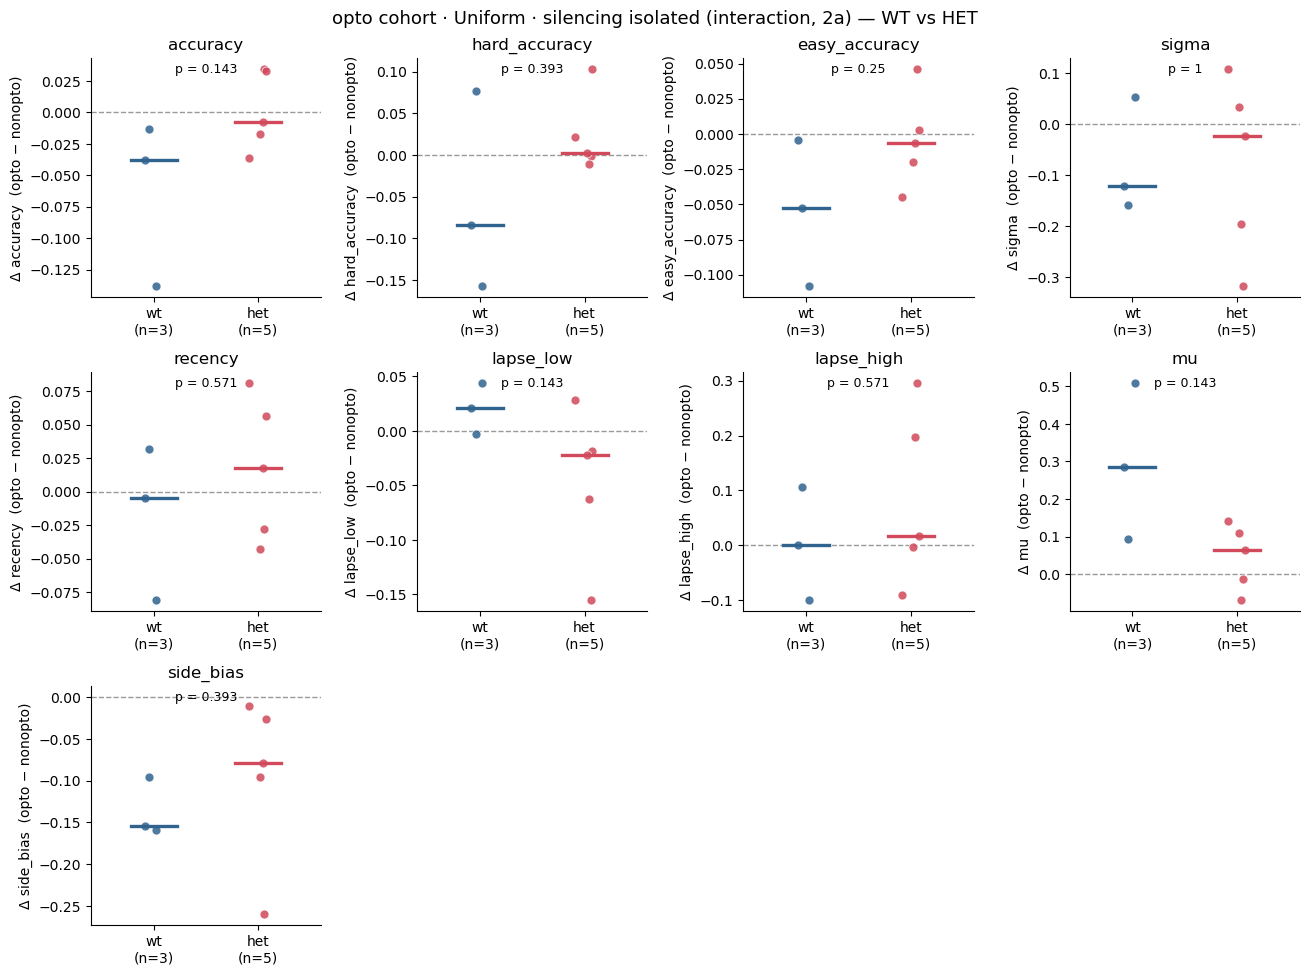

In [14]:
# §4c — 2a (interaction, silencing beyond artifact), WT vs HET
if len(interaction_df):
    res_2a, tbl_2a = genotype_table(interaction_df)
    swarm_grid(interaction_df, res_2a, f'opto cohort · {DIST} · silencing isolated (interaction, 2a) — WT vs HET')
    display(tbl_2a) if 'display' in dir() else print(tbl_2a.to_string())
else:
    print('No interaction rows (masking missing).')

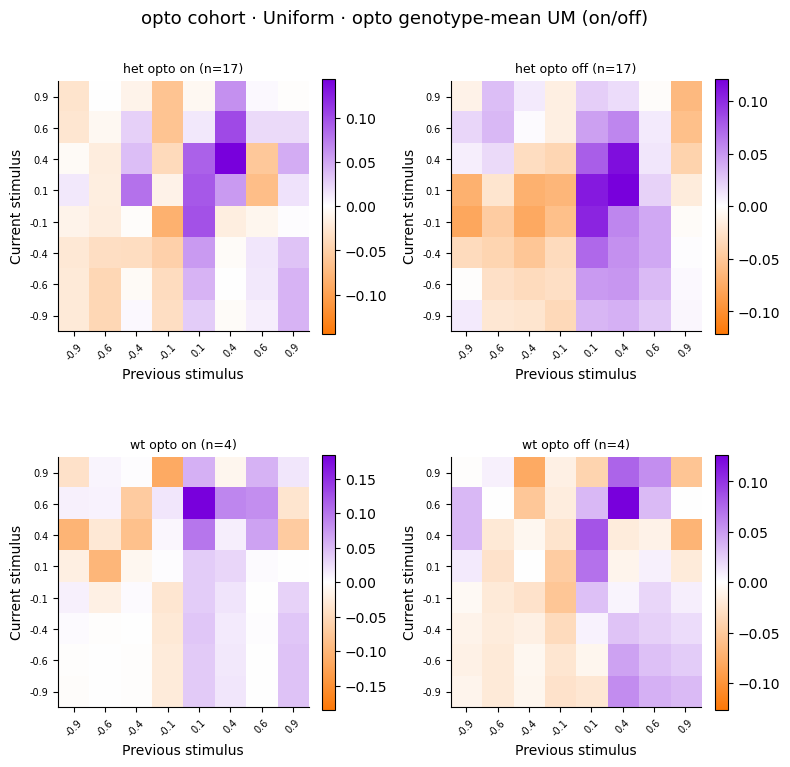

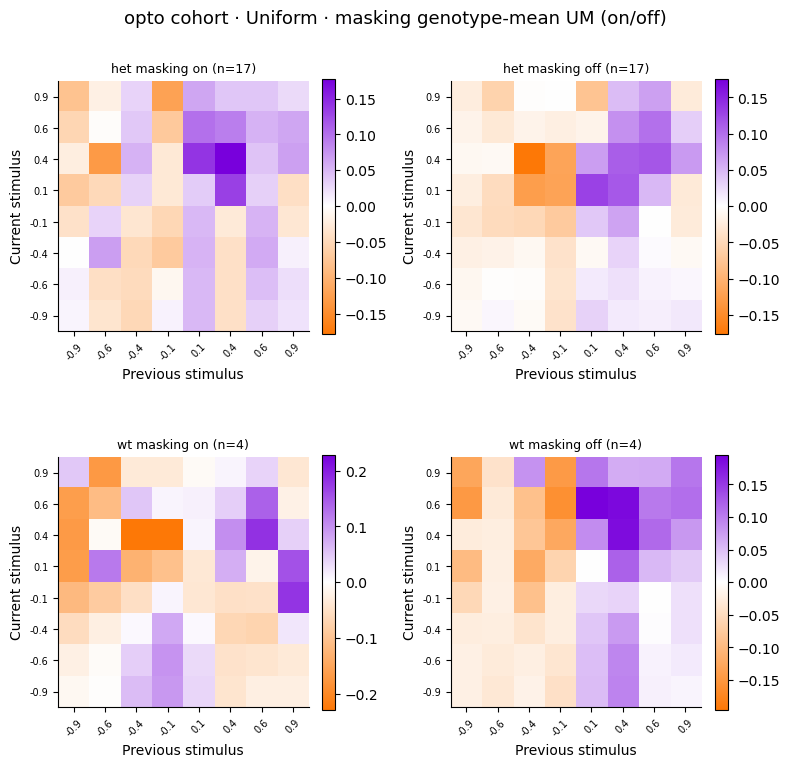

In [15]:
# §4d — genotype-mean update matrices ({het,wt} x {opto,masking} on/off)
def cond_ums(ids, session_type, trial_type):
    out = []
    for a in ids:
        ph = select_sessions(experiment.get_animal(a), distribution=DIST, session_type=session_type)
        c = filter_trials(ph, trial_type=trial_type)
        if c: out.append(compute_um(c))
    return out

for stype in ['opto', 'masking']:
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), squeeze=False)
    for row, g in enumerate(['het', 'wt']):
        ids = groups.get(g, [])
        for col, tt in enumerate(['opto', 'non_opto']):
            ums = cond_ums(ids, stype, tt)
            if ums: plot_um(average_um(ums, min_sources=2), ax=axes[row, col])
            axes[row, col].set_title(f"{g} {stype} {'on' if tt=='opto' else 'off'} (n={len(ids)})", fontsize=9)
    fig.suptitle(f"opto cohort · {DIST} · {stype} genotype-mean UM (on/off)", fontsize=13); fig.tight_layout()

## §5 · Specificity — ALM control

Silencing ALM instead of PPC, three contrasts (all `alm_control_uni` animals; the
one without ALM skips). Together they localise any effect to PPC:

1. **opto on vs off within ALM sessions** (1c on ALM) — is there a laser effect when
   ALM is silenced? Permutation-valid.
2. **ALM vs masking sessions**, all trials — does silencing ALM differ from the pure
   light event? Bootstrap CI.
3. **ALM vs PPC-opto sessions**, all trials — is the effect PPC-specific or a generic
   consequence of inhibiting *any* area? Bootstrap CI.

If PPC-opto moves behaviour, ALM ≈ masking, and ALM ≠ PPC-opto → the effect is
PPC-specific silencing, not light and not generic cortical inhibition.

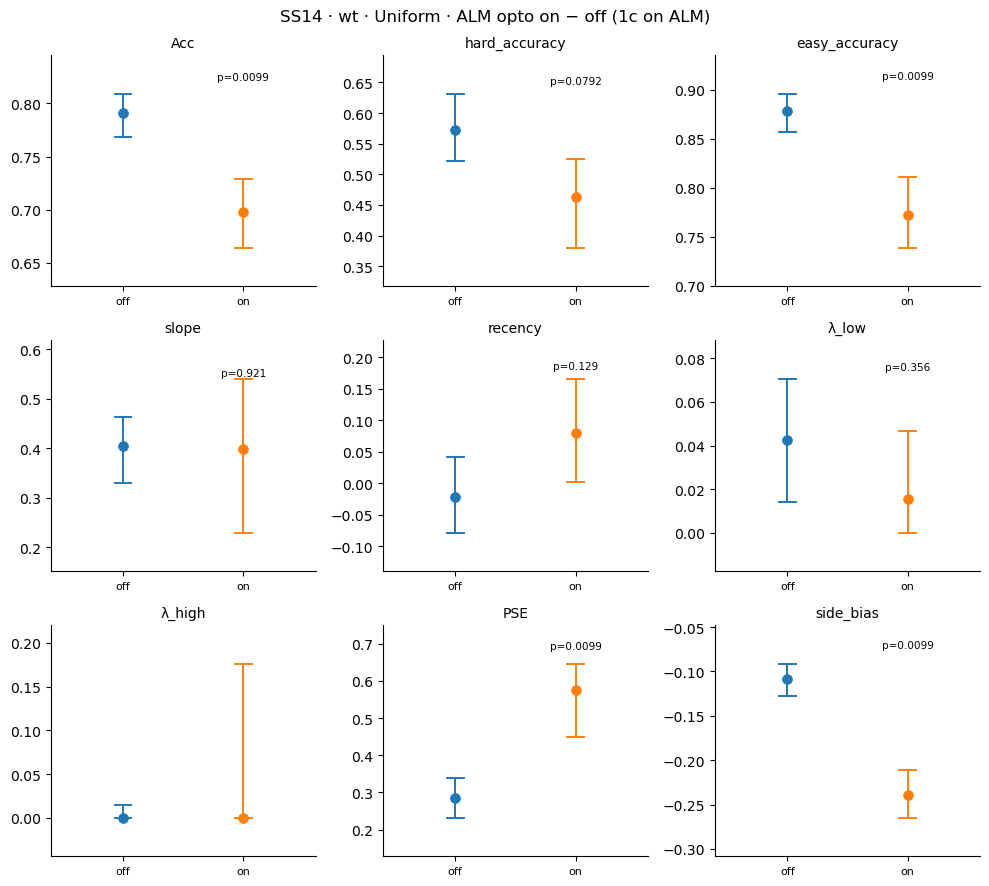

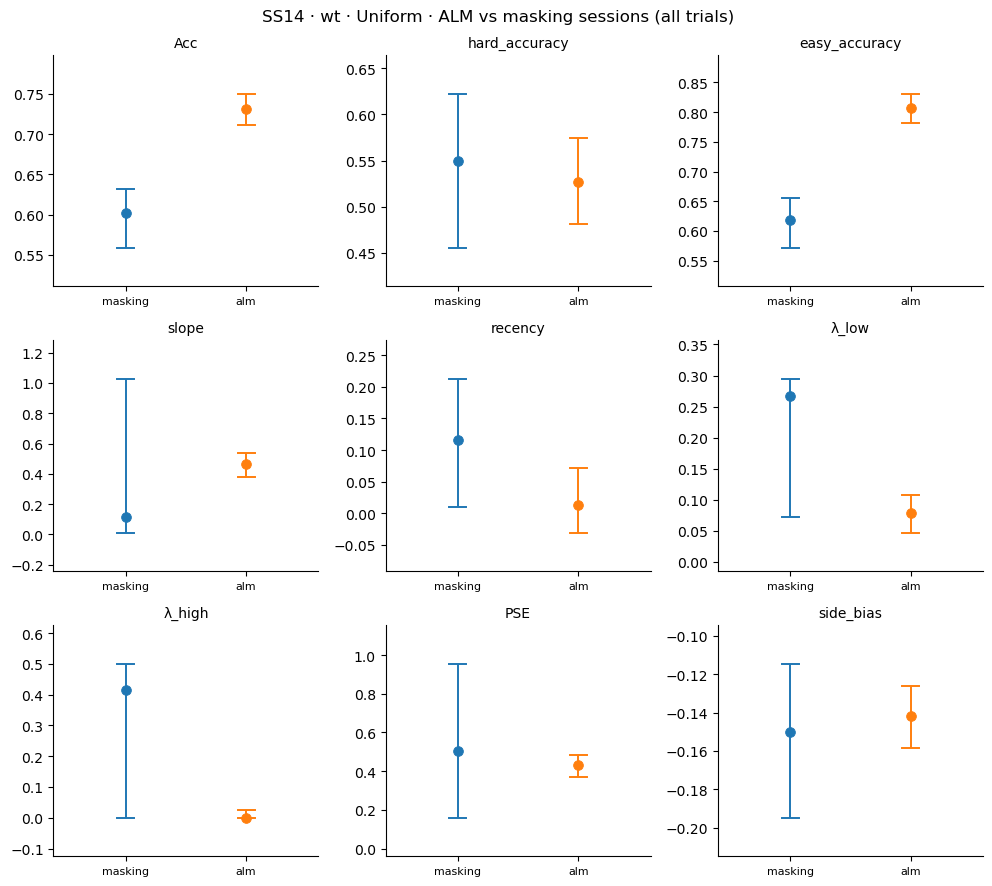

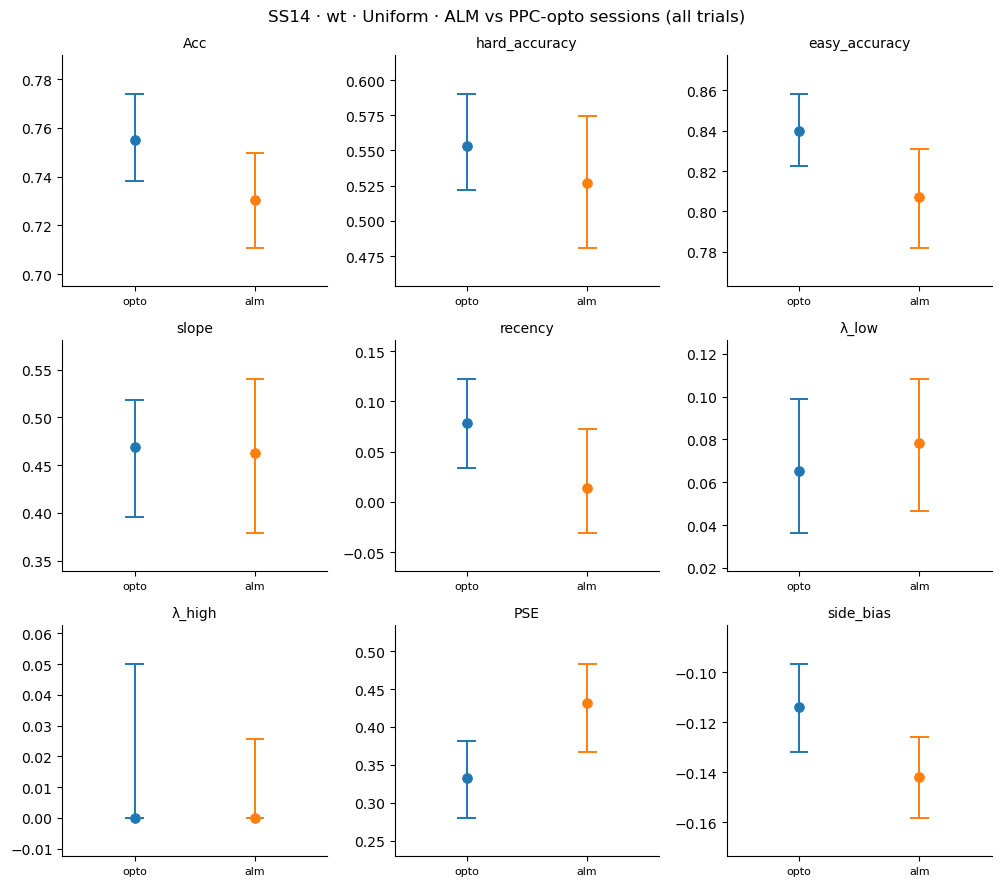

In [16]:
ALM_STYPE = 'alm_control_uni'
alm_ex = next((a for a in opto_ids
               if select_sessions(experiment.get_animal(a), distribution=DIST, session_type=ALM_STYPE)), None)
if alm_ex is None:
    print('No ALM-control sessions in this cohort — specificity deferred.')
else:
    a = experiment.get_animal(alm_ex)
    alm = select_sessions(a, distribution=DIST, session_type=ALM_STYPE)
    mk  = select_sessions(a, distribution=DIST, session_type='masking')
    op  = select_sessions(a, distribution=DIST, session_type='opto')
    a_on, a_off = filter_trials(alm, trial_type='opto'), filter_trials(alm, trial_type='non_opto')
    a_all, m_all, o_all = (filter_trials(alm, trial_type='all'),
                           filter_trials(mk, trial_type='all'), filter_trials(op, trial_type='all'))
    panels = []
    if a_on and a_off:
        panels.append((compute_delta_stat({'on': a_on, 'off': a_off}, stats=STATS, reference='off',
                       n_permutations=N_PERM, n_bootstrap=N_BOOT), 'ALM opto on − off (1c on ALM)'))
    if a_all and m_all:
        panels.append((compute_delta_stat({'alm': a_all, 'masking': m_all}, stats=STATS, reference='masking',
                       n_permutations=0, n_bootstrap=N_BOOT), 'ALM vs masking sessions (all trials)'))
    if a_all and o_all:
        panels.append((compute_delta_stat({'alm': a_all, 'opto': o_all}, stats=STATS, reference='opto',
                       n_permutations=0, n_bootstrap=N_BOOT), 'ALM vs PPC-opto sessions (all trials)'))
    for res_d, label in panels:
        fig, axes = plt.subplots(3, 3, figsize=(10, 9)); axf = axes.ravel()
        for ax, stat in zip(axf, DISPLAY): plot_stat_comparison_single(res_d, stat, ax=ax)
        for ax in axf[len(DISPLAY):]: fig.delaxes(ax)
        fig.suptitle(f"{alm_ex} · {by_animal[alm_ex]} · {DIST} · {label}", fontsize=12); fig.tight_layout()

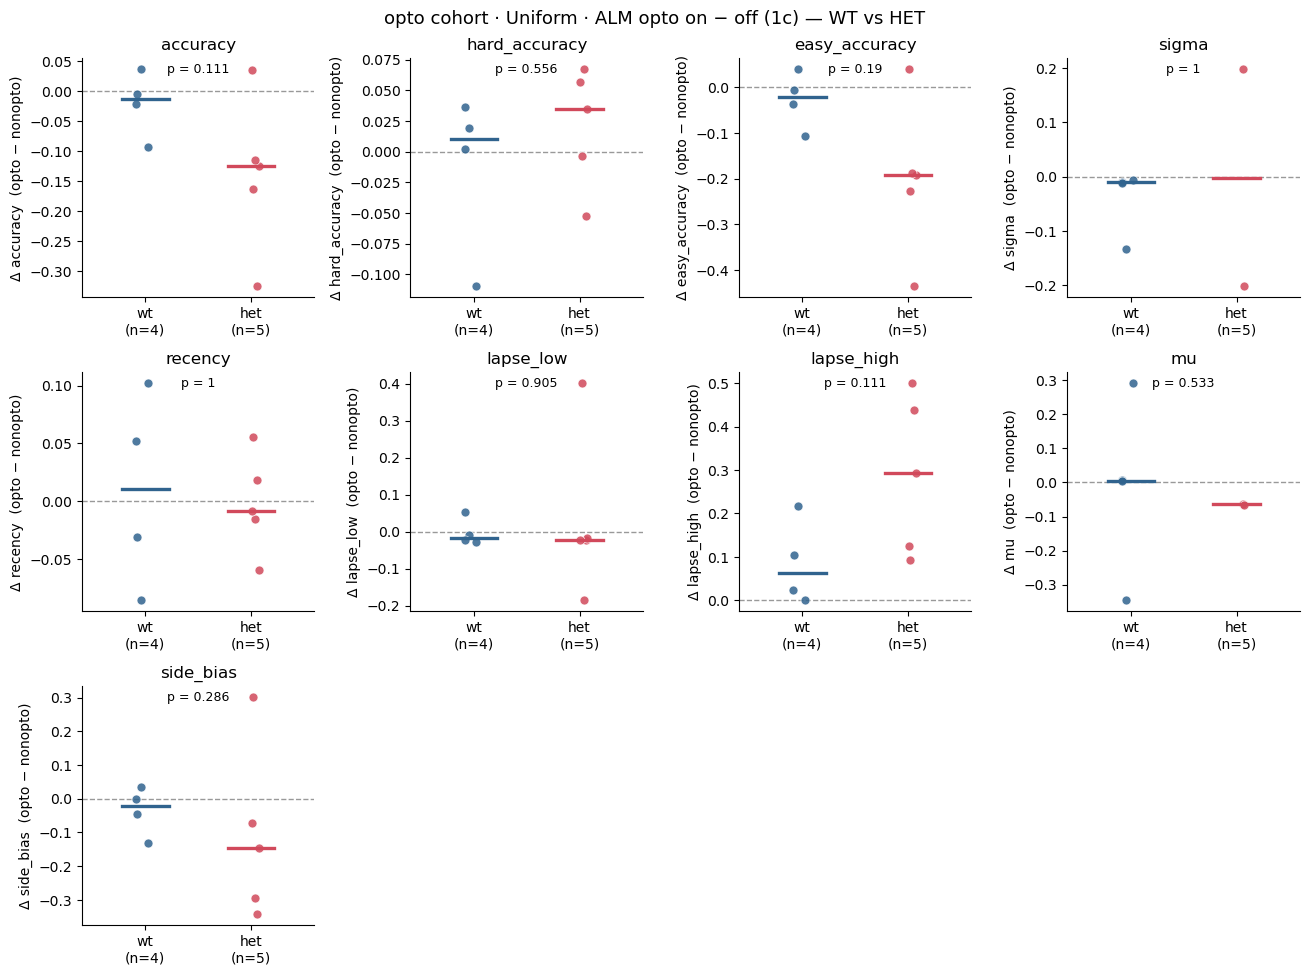

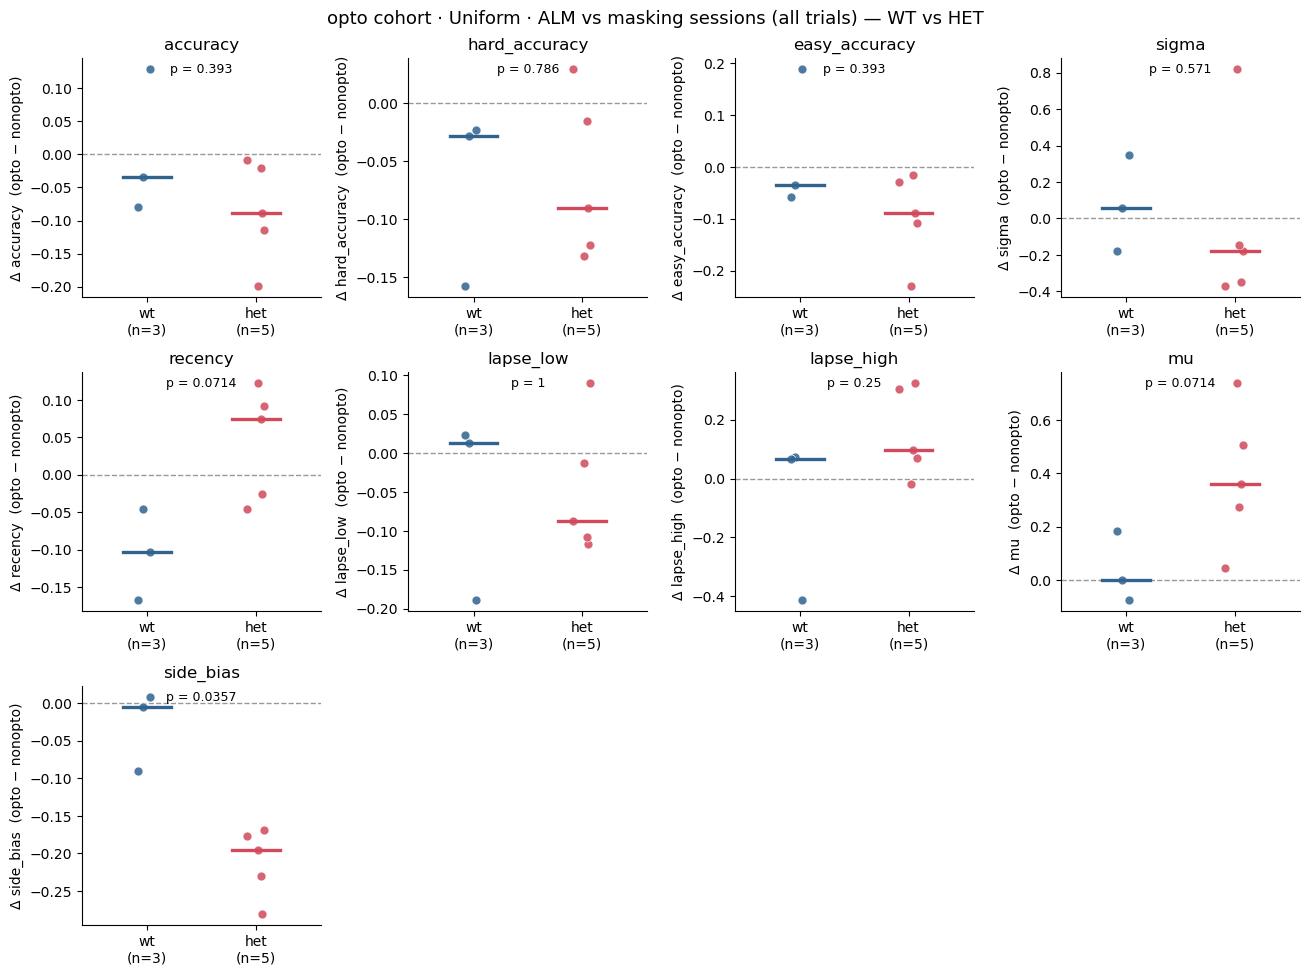

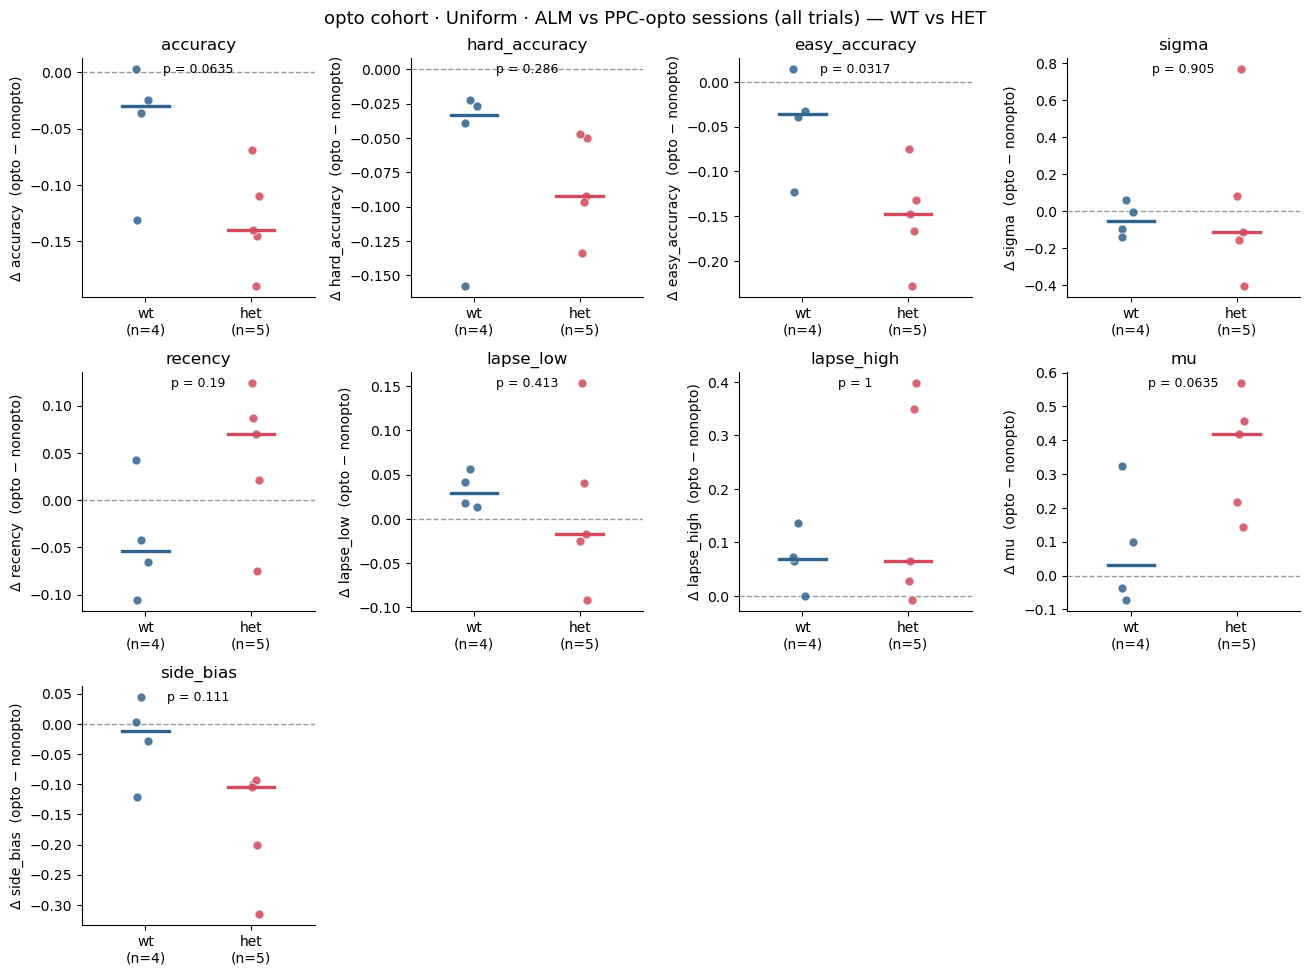

In [17]:
# ALM fold: the three contrasts across ALM animals, then WT vs HET
alm_1c, alm_mask, alm_opto = [], [], []
for aid in opto_ids:
    a = experiment.get_animal(aid)
    alm = select_sessions(a, distribution=DIST, session_type=ALM_STYPE)
    if not alm: continue
    mk = select_sessions(a, distribution=DIST, session_type='masking')
    op = select_sessions(a, distribution=DIST, session_type='opto')
    a_on, a_off = filter_trials(alm, trial_type='opto'), filter_trials(alm, trial_type='non_opto')
    a_all, m_all, o_all = (filter_trials(alm, trial_type='all'),
                           filter_trials(mk, trial_type='all'), filter_trials(op, trial_type='all'))
    if a_on and a_off:
        d = compute_delta_stat({'on': a_on, 'off': a_off}, stats=STATS, reference='off',
                               n_permutations=N_PERM, n_bootstrap=N_BOOT)
        alm_1c += rows_from(d['contrasts']['on_vs_off']['diffs'], aid)
    if a_all and m_all:
        d = compute_delta_stat({'alm': a_all, 'masking': m_all}, stats=STATS, reference='masking',
                               n_permutations=0, n_bootstrap=N_BOOT)
        alm_mask += rows_from(d['contrasts']['alm_vs_masking']['diffs'], aid)
    if a_all and o_all:
        d = compute_delta_stat({'alm': a_all, 'opto': o_all}, stats=STATS, reference='opto',
                               n_permutations=0, n_bootstrap=N_BOOT)
        alm_opto += rows_from(d['contrasts']['alm_vs_opto']['diffs'], aid)

alm_1c_df, alm_mask_df, alm_opto_df = pd.DataFrame(alm_1c), pd.DataFrame(alm_mask), pd.DataFrame(alm_opto)
for name, df, title in [('ALM 1c (on−off)', alm_1c_df, 'ALM opto on − off (1c) — WT vs HET'),
                        ('ALM vs masking', alm_mask_df, 'ALM vs masking sessions (all trials) — WT vs HET'),
                        ('ALM vs PPC-opto', alm_opto_df, 'ALM vs PPC-opto sessions (all trials) — WT vs HET')]:
    if not len(df):
        print(f'{name}: no rows'); continue
    res, _ = genotype_table(df)
    swarm_grid(df, res, f'opto cohort · {DIST} · {title}')

## §6 · Emit

The three per-animal contrast sets, for nb 43 (opto × model).

In [18]:
# try:
#     out = FIG_DIR.parent / 'results'; out.mkdir(parents=True, exist_ok=True)
#     delta_df.to_csv(out / '20_uniform_1c.csv', index=False)
#     between_df.to_csv(out / '20_uniform_2b.csv', index=False)
#     interaction_df.to_csv(out / '20_uniform_2a.csv', index=False)
#     print(f'wrote 1c/2b/2a ({len(delta_df)}/{len(between_df)}/{len(interaction_df)} rows) to {out}')
# except Exception as e:
#     print(f'emit skipped: {e}')